# 03. EDA and Feature Engineering

## Objective

This notebook performs exploratory data analysis and creates the customer-level
features required for downstream diagnostic analysis.

The analytical grain is **one row per customer**.

The analysis focuses on:

- Repeat-purchase behaviour
- First-order delivery performance
- First-order freight burden
- First-order order value
- Payment behaviour
- Customer value segments
- Delivery vs value-tier patterns

Feature engineering is limited to variables with a clear analytical meaning.
No formal hypothesis test or predictive model is performed here.

The notebook includes descriptive charts to make the main patterns easier to interpret.

## 1. Connect to the Analytical Data Layer

The customer-level analytical table created in Notebook 02 is used as the
starting point.

The persistent database is opened in read/write mode so the engineered
tables and features can be retained for later notebooks.

In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
DUCKDB_PATH = PROJECT_ROOT / "04_DuckDB" / "olist_capstone.duckdb"
ANALYTICAL_DIR = PROJECT_ROOT / "02_Data" / "03_Analytical"
ANALYTICAL_DIR.mkdir(parents=True, exist_ok=True)

if not DUCKDB_PATH.exists():
    raise FileNotFoundError(f"DuckDB database not found: {DUCKDB_PATH}")

con = duckdb.connect(str(DUCKDB_PATH))

print(f"DuckDB version: {duckdb.__version__}")
print(f"Database: {DUCKDB_PATH}")

DuckDB version: 1.5.5
Database: d:\Learning\Data Science\Capstone Project\Final_Project_Olist_BYOC_Capstone\04_DuckDB\olist_capstone.duckdb


## 2. Confirm the Analytical Population

The analysis uses the first order for each customer whose first order has a
valid actual customer delivery date.

The repeat-purchase flag is already defined at customer level.

In [2]:
population = con.sql("""
SELECT
    COUNT(*) AS customers,
    COUNT(DISTINCT customer_unique_id) AS unique_customer_identities,
    SUM(is_repeat_customer) AS repeat_customers,
    100.0 * AVG(is_repeat_customer) AS repeat_purchase_rate_pct,
    SUM(CASE WHEN is_late = 1 THEN 1 ELSE 0 END) AS first_orders_late,
    SUM(CASE WHEN is_late = 0 THEN 1 ELSE 0 END) AS first_orders_on_time_or_early,
    100.0 * AVG(CASE WHEN is_late IS NOT NULL THEN is_late END)
        AS first_order_late_rate_pct
FROM customer_level_analytical
""").df()

display(population)

display(con.sql("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT customer_unique_id) AS unique_customers,
    COUNT(*) - COUNT(DISTINCT customer_unique_id) AS duplicate_customer_rows
FROM customer_level_analytical
""").df())

,customers,unique_customer_identities,repeat_customers,repeat_purchase_rate_pct,first_orders_late,first_orders_on_time_or_early,first_order_late_rate_pct
0,93254,93254,2877.0,3.085122,7592.0,85662.0,8.141206


,rows,unique_customers,duplicate_customer_rows
0,93254,93254,0


## 3. Inspect the Main Analytical Variables

Review the first-order variables used throughout the notebook.

The descriptive statistics are used to understand the distribution before
creating bands and customer segments.

In [3]:
main_features = [
    "delivery_duration_days",
    "delivery_delay_days",
    "total_price",
    "total_freight",
    "freight_to_price_ratio",
    "total_payment_value",
    "max_installments",
    "review_score_avg",
    "is_late",
    "is_repeat_customer"
]

available_features = [
    c for c in main_features
    if c in con.sql("SELECT * FROM customer_level_analytical LIMIT 0").df().columns
]

display(con.sql(f"""
SELECT
    COUNT(*) AS customers,
    AVG(delivery_duration_days) AS avg_delivery_duration_days,
    MEDIAN(delivery_duration_days) AS median_delivery_duration_days,
    AVG(delivery_delay_days) AS avg_delivery_delay_days,
    MEDIAN(delivery_delay_days) AS median_delivery_delay_days,
    AVG(total_price) AS avg_order_value,
    MEDIAN(total_price) AS median_order_value,
    AVG(total_freight) AS avg_freight,
    MEDIAN(total_freight) AS median_freight,
    AVG(freight_to_price_ratio) AS avg_freight_ratio,
    MEDIAN(freight_to_price_ratio) AS median_freight_ratio
FROM customer_level_analytical
""").df())

,customers,avg_delivery_duration_days,median_delivery_duration_days,avg_delivery_delay_days,median_delivery_delay_days,avg_order_value,median_order_value,avg_freight,median_freight,avg_freight_ratio,median_freight_ratio
0,93254,12.570031,10.217124,-11.155591,-11.893843,137.478804,86.9,22.775927,17.18,0.307864,0.224374


## 4. Delivery Performance

Describe the first-order delivery experience.

The delivery delay is measured against the estimated delivery date.
Positive delay values represent delivery after the estimated date.

In [4]:
delivery_summary = con.sql("""
SELECT
    COUNT(*) AS customers,
    COUNT(delivery_duration_days) AS valid_delivery_duration,
    MEDIAN(delivery_duration_days) AS median_delivery_duration_days,
    QUANTILE_CONT(delivery_duration_days, 0.25) AS q1_delivery_duration_days,
    QUANTILE_CONT(delivery_duration_days, 0.75) AS q3_delivery_duration_days,
    MAX(delivery_duration_days) AS max_delivery_duration_days,
    MEDIAN(delivery_delay_days) AS median_delivery_delay_days,
    QUANTILE_CONT(delivery_delay_days, 0.25) AS q1_delivery_delay_days,
    QUANTILE_CONT(delivery_delay_days, 0.75) AS q3_delivery_delay_days,
    MAX(delivery_delay_days) AS max_delivery_delay_days
FROM customer_level_analytical
""").df()

display(delivery_summary)

delivery_status = con.sql("""
SELECT
    CASE
        WHEN is_late = 1 THEN 'Late'
        WHEN is_late = 0 THEN 'On-time / early'
        ELSE 'Unclassified'
    END AS delivery_group,
    COUNT(*) AS customers,
    SUM(is_repeat_customer) AS repeat_customers,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct
FROM customer_level_analytical
GROUP BY 1
ORDER BY
    CASE delivery_group
        WHEN 'On-time / early' THEN 1
        WHEN 'Late' THEN 2
        ELSE 3
    END
""").df()

display(delivery_status)

,customers,valid_delivery_duration,median_delivery_duration_days,q1_delivery_duration_days,q3_delivery_duration_days,max_delivery_duration_days,median_delivery_delay_days,q1_delivery_delay_days,q3_delivery_delay_days,max_delivery_delay_days
0,93254,93254,10.217124,6.770437,15.73305,209.628611,-11.893843,-16.237781,-6.382653,188.975081


,delivery_group,customers,repeat_customers,repeat_rate_pct
0,On-time / early,85662,2683.0,3.132077
1,Late,7592,194.0,2.555321


### 4.1 Delivery Duration Distribution

The distribution of first-order delivery duration is visualized to show the
typical delivery time and the presence of unusually long deliveries.

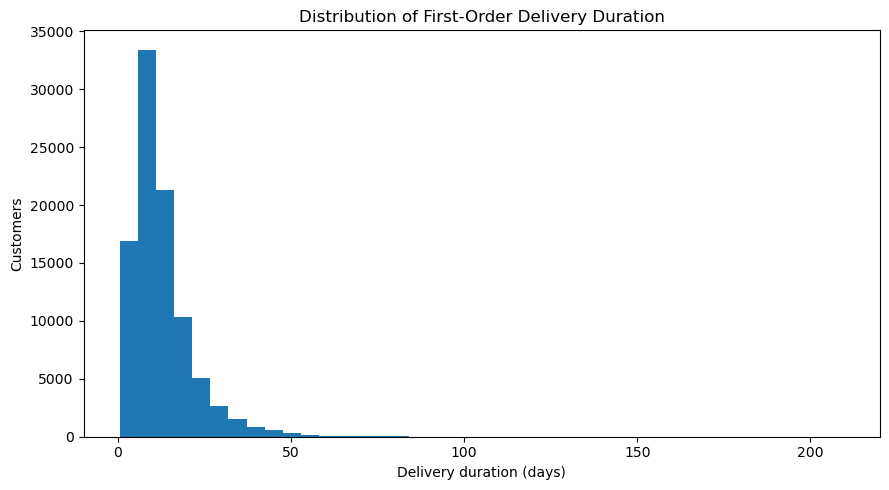

In [5]:
delivery_duration_plot = con.sql("""
SELECT delivery_duration_days
FROM customer_level_featured
WHERE delivery_duration_days IS NOT NULL
""").df()

plt.figure(figsize=(9, 5))
plt.hist(delivery_duration_plot["delivery_duration_days"], bins=40)
plt.xlabel("Delivery duration (days)")
plt.ylabel("Customers")
plt.title("Distribution of First-Order Delivery Duration")
plt.tight_layout()
plt.show()

## 5. Univariate EDA — Order Value and Freight

Explore first-order value, freight and freight burden.

The distributions are expected to be right-skewed, so both mean and median
are retained for comparison.

In [6]:
value_summary = con.sql("""
SELECT
    COUNT(*) AS customers,

    AVG(total_price) AS avg_order_value,
    MEDIAN(total_price) AS median_order_value,
    QUANTILE_CONT(total_price, 0.25) AS q1_order_value,
    QUANTILE_CONT(total_price, 0.75) AS q3_order_value,
    QUANTILE_CONT(total_price, 0.90) AS p90_order_value,
    QUANTILE_CONT(total_price, 0.95) AS p95_order_value,
    QUANTILE_CONT(total_price, 0.99) AS p99_order_value,
    MAX(total_price) AS max_order_value,

    AVG(total_freight) AS avg_freight,
    MEDIAN(total_freight) AS median_freight,
    QUANTILE_CONT(total_freight, 0.25) AS q1_freight,
    QUANTILE_CONT(total_freight, 0.75) AS q3_freight,
    QUANTILE_CONT(total_freight, 0.99) AS p99_freight,
    MAX(total_freight) AS max_freight,

    AVG(freight_to_price_ratio) AS avg_freight_ratio,
    MEDIAN(freight_to_price_ratio) AS median_freight_ratio,
    QUANTILE_CONT(freight_to_price_ratio, 0.25) AS q1_freight_ratio,
    QUANTILE_CONT(freight_to_price_ratio, 0.75) AS q3_freight_ratio,
    QUANTILE_CONT(freight_to_price_ratio, 0.99) AS p99_freight_ratio,
    MAX(freight_to_price_ratio) AS max_freight_ratio
FROM customer_level_analytical
""").df()

display(value_summary)

,customers,avg_order_value,median_order_value,q1_order_value,q3_order_value,p90_order_value,p95_order_value,p99_order_value,max_order_value,avg_freight,...,q1_freight,q3_freight,p99_freight,max_freight,avg_freight_ratio,median_freight_ratio,q1_freight_ratio,q3_freight_ratio,p99_freight_ratio,max_freight_ratio
0,93254,137.478804,86.9,45.9,149.9,269.7,399.6,998.0,13440.0,22.775927,...,13.85,24.01,104.5805,1794.96,0.307864,0.224374,0.131864,0.380114,1.453369,21.447059


## 6. Univariate EDA — Payment Behaviour

Explore the number of payment records and the maximum installment count
associated with the first order.

In [7]:
display(con.sql("""
SELECT
    COUNT(*) AS customers,
    AVG(payment_count) AS avg_payment_count,
    MEDIAN(payment_count) AS median_payment_count,
    MAX(payment_count) AS max_payment_count,
    AVG(max_installments) AS avg_max_installments,
    MEDIAN(max_installments) AS median_max_installments,
    MAX(max_installments) AS max_installments
FROM customer_level_analytical
""").df())

display(con.sql("""
SELECT
    max_installments,
    COUNT(*) AS customers,
    100.0 * COUNT(*) / SUM(COUNT(*)) OVER () AS pct_customers
FROM customer_level_analytical
GROUP BY max_installments
ORDER BY max_installments
LIMIT 30
""").df())

,customers,avg_payment_count,median_payment_count,max_payment_count,avg_max_installments,median_max_installments,max_installments
0,93254,1.043763,1.0,26,2.915038,2.0,24


,max_installments,customers,pct_customers
0,0,2,0.002145
1,1,45353,48.633839
2,2,11689,12.534583
3,3,9808,10.517511
4,4,6635,7.114976
5,5,4880,5.233019
6,6,3641,3.904390
7,7,1492,1.599931
8,8,3946,4.231454
9,9,591,0.633753


In [8]:
h1_delivery_plot = con.sql("""
SELECT
    CASE
        WHEN first_order_late_flag = 1 THEN 'Late'
        ELSE 'On-time / early'
    END AS delivery_group,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct
FROM customer_level_featured
WHERE first_order_late_flag IS NOT NULL
  AND is_repeat_customer IS NOT NULL
GROUP BY first_order_late_flag
ORDER BY first_order_late_flag
""").df()

### 7.1 Repeat-Purchase Rate by Delivery Status

This chart provides a direct visual comparison of repeat-purchase rates for
late and on-time/early first orders.

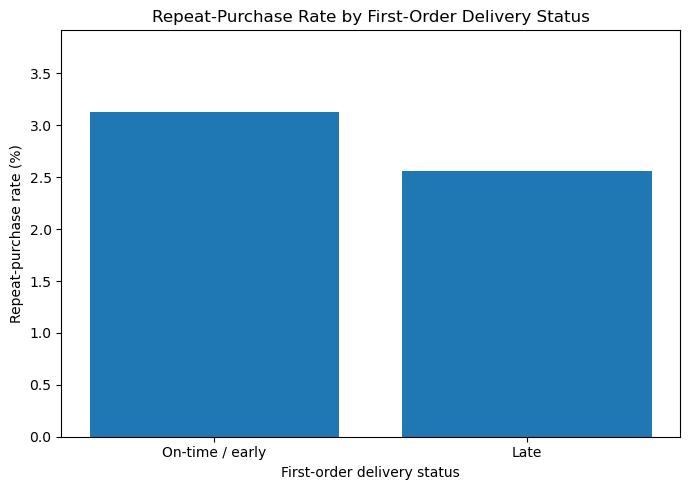

In [9]:
plt.figure(figsize=(7, 5))
plt.bar(
    h1_delivery_plot["delivery_group"],
    h1_delivery_plot["repeat_rate_pct"]
)
plt.ylabel("Repeat-purchase rate (%)")
plt.xlabel("First-order delivery status")
plt.title("Repeat-Purchase Rate by First-Order Delivery Status")
plt.ylim(0, max(h1_delivery_plot["repeat_rate_pct"]) * 1.25)
plt.tight_layout()
plt.show()

## 7. Repeat Purchase by Delivery Status

Compare descriptive repeat-purchase rates between customers whose first
order was late and those whose first order was on time or early.

This section is descriptive only.

In [10]:
repeat_by_delivery = con.sql("""
SELECT
    CASE
        WHEN is_late = 1 THEN 'Late'
        WHEN is_late = 0 THEN 'On-time / early'
        ELSE 'Unclassified'
    END AS delivery_group,
    COUNT(*) AS customers,
    SUM(is_repeat_customer) AS repeat_customers,
    AVG(is_repeat_customer) AS repeat_rate,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct
FROM customer_level_analytical
GROUP BY 1
ORDER BY
    CASE delivery_group
        WHEN 'On-time / early' THEN 1
        WHEN 'Late' THEN 2
        ELSE 3
    END
""").df()

display(repeat_by_delivery)

,delivery_group,customers,repeat_customers,repeat_rate,repeat_rate_pct
0,On-time / early,85662,2683.0,0.031321,3.132077
1,Late,7592,194.0,0.025553,2.555321


## 8. Feature Engineering — Freight Burden Bands

Create four bands using quartiles of first-order freight burden.

The bands are based on the observed distribution and are used for descriptive
comparison and downstream analysis.

In [11]:
con.execute("""
CREATE OR REPLACE TABLE customer_level_featured AS
WITH base AS (
    SELECT *
    FROM customer_level_analytical
),
q_ratio AS (
    SELECT
        *,
        QUANTILE_CONT(freight_to_price_ratio, 0.25) OVER ()
            AS freight_ratio_q1,
        QUANTILE_CONT(freight_to_price_ratio, 0.50) OVER ()
            AS freight_ratio_q2,
        QUANTILE_CONT(freight_to_price_ratio, 0.75) OVER ()
            AS freight_ratio_q3,
        QUANTILE_CONT(total_freight, 0.25) OVER ()
            AS freight_value_q1,
        QUANTILE_CONT(total_freight, 0.50) OVER ()
            AS freight_value_q2,
        QUANTILE_CONT(total_freight, 0.75) OVER ()
            AS freight_value_q3
    FROM base
)
SELECT
    *,
    CASE
        WHEN freight_to_price_ratio <= freight_ratio_q1 THEN 'Low freight burden'
        WHEN freight_to_price_ratio <= freight_ratio_q2 THEN 'Medium-low freight burden'
        WHEN freight_to_price_ratio <= freight_ratio_q3 THEN 'Medium-high freight burden'
        ELSE 'High freight burden'
    END AS freight_ratio_band,
    CASE
        WHEN total_freight <= freight_value_q1 THEN 'Low freight burden'
        WHEN total_freight <= freight_value_q2 THEN 'Medium-low freight burden'
        WHEN total_freight <= freight_value_q3 THEN 'Medium-high freight burden'
        ELSE 'High freight burden'
    END AS freight_burden_band
FROM q_ratio
""")

band_comparison = con.sql("""
SELECT * FROM (
    SELECT
        'freight_ratio_band (original, ratio-based)' AS band_type,
        freight_ratio_band AS band,
        COUNT(*) AS customers,
        SUM(is_repeat_customer) AS repeat_customers,
        100.0 * AVG(is_repeat_customer) AS repeat_rate_pct
    FROM customer_level_featured
    GROUP BY freight_ratio_band
    UNION ALL
    SELECT
        'freight_burden_band (corrected, value-based)' AS band_type,
        freight_burden_band AS band,
        COUNT(*) AS customers,
        SUM(is_repeat_customer) AS repeat_customers,
        100.0 * AVG(is_repeat_customer) AS repeat_rate_pct
    FROM customer_level_featured
    GROUP BY freight_burden_band
) AS combined
ORDER BY band_type,
    CASE band
        WHEN 'Low freight burden' THEN 1
        WHEN 'Medium-low freight burden' THEN 2
        WHEN 'Medium-high freight burden' THEN 3
        WHEN 'High freight burden' THEN 4
    END
""").df()

display(band_comparison)


,band_type,band,customers,repeat_customers,repeat_rate_pct
0,"freight_burden_band (corrected, value-based)",Low freight burden,23325,737.0,3.159700
1,"freight_burden_band (corrected, value-based)",Medium-low freight burden,23318,785.0,3.366498
2,"freight_burden_band (corrected, value-based)",Medium-high freight burden,23302,617.0,2.647841
3,"freight_burden_band (corrected, value-based)",High freight burden,23309,738.0,3.166159
4,"freight_ratio_band (original, ratio-based)",Low freight burden,23317,666.0,2.856285
5,"freight_ratio_band (original, ratio-based)",Medium-low freight burden,23409,727.0,3.105643
6,"freight_ratio_band (original, ratio-based)",Medium-high freight burden,23222,684.0,2.945483
7,"freight_ratio_band (original, ratio-based)",High freight burden,23306,800.0,3.432592


### Freight Banding Correction — Result

Compare the two bandings above directly. If the ratio-based band shows a
different direction of effect than the value-based band, that is direct
evidence the ratio-based split was distorted by its mechanical dependence
on order value. **All downstream H2 analysis uses
`freight_burden_band` (value-based).** `freight_ratio_band` is retained
only for transparency.


## 9. Feature Engineering — Customer Value Tiers

Create four customer-value tiers using quartiles of first-order order value.

The tiers are descriptive segments and do not imply a causal relationship
between order value and repeat purchase.

In [12]:
con.execute("""
CREATE OR REPLACE TABLE customer_level_featured AS
WITH q AS (
    SELECT
        *,
        QUANTILE_CONT(total_price, 0.25) OVER () AS value_q1,
        QUANTILE_CONT(total_price, 0.50) OVER () AS value_q2,
        QUANTILE_CONT(total_price, 0.75) OVER () AS value_q3
    FROM customer_level_featured
)
SELECT
    *,
    CASE
        WHEN total_price <= value_q1 THEN 'Low'
        WHEN total_price <= value_q2 THEN 'Medium-Low'
        WHEN total_price <= value_q3 THEN 'Medium-High'
        ELSE 'High'
    END AS value_tier
FROM q
""")

value_tier = con.sql("""
SELECT
    value_tier,
    COUNT(*) AS customers,
    AVG(total_price) AS avg_order_value,
    MEDIAN(total_price) AS median_order_value,
    AVG(is_repeat_customer) AS repeat_rate,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct
FROM customer_level_featured
GROUP BY value_tier
ORDER BY
    CASE value_tier
        WHEN 'Low' THEN 1
        WHEN 'Medium-Low' THEN 2
        WHEN 'Medium-High' THEN 3
        WHEN 'High' THEN 4
    END
""").df()

display(value_tier)

,value_tier,customers,avg_order_value,median_order_value,repeat_rate,repeat_rate_pct
0,Low,23400,28.613741,29.00,0.032179,3.217949
1,Medium-Low,23293,63.944420,60.00,0.032413,3.241317
2,Medium-High,23401,115.103533,113.45,0.029358,2.935772
3,High,23160,344.036777,230.00,0.029447,2.944732


## 10. Repeat Purchase Across Freight-Burden Bands

Compare customer counts and repeat-purchase rates across the four freight
burden bands.

In [13]:
freight_repeat = con.sql("""
SELECT
    freight_burden_band,
    COUNT(*) AS customers,
    SUM(is_repeat_customer) AS repeat_customers,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct
FROM customer_level_featured
GROUP BY freight_burden_band
ORDER BY
    CASE freight_burden_band
        WHEN 'Low freight burden' THEN 1
        WHEN 'Medium-low freight burden' THEN 2
        WHEN 'Medium-high freight burden' THEN 3
        WHEN 'High freight burden' THEN 4
    END
""").df()

display(freight_repeat)

,freight_burden_band,customers,repeat_customers,repeat_rate_pct
0,Low freight burden,23325,737.0,3.159700
1,Medium-low freight burden,23318,785.0,3.366498
2,Medium-high freight burden,23302,617.0,2.647841
3,High freight burden,23309,738.0,3.166159


In [14]:
freight_repeat_plot = con.sql("""
SELECT
    freight_burden_band,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct
FROM customer_level_featured
WHERE freight_burden_band IS NOT NULL
GROUP BY freight_burden_band
ORDER BY
    CASE freight_burden_band
        WHEN 'Low freight burden' THEN 1
        WHEN 'Medium-low freight burden' THEN 2
        WHEN 'Medium-high freight burden' THEN 3
        WHEN 'High freight burden' THEN 4
    END
""").df()

### 10.1 Repeat-Purchase Rate by Freight-Burden Band

The chart shows how repeat-purchase rates vary across the four freight-burden
bands.

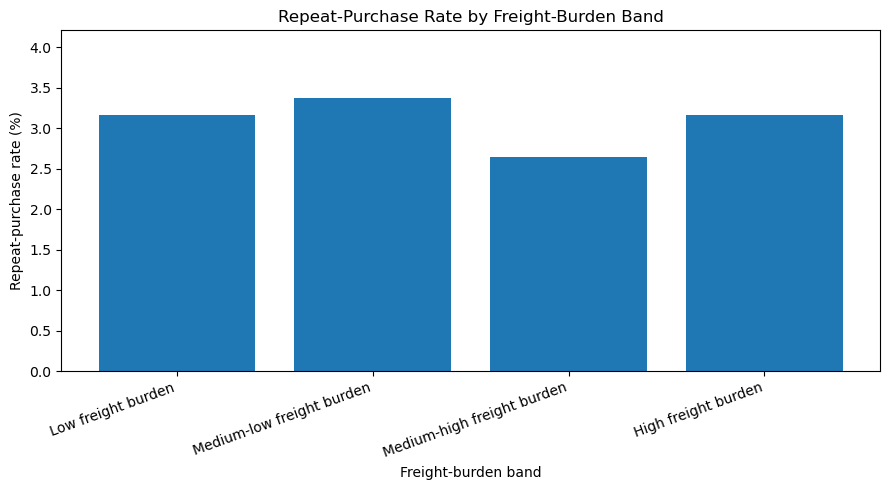

In [15]:
plt.figure(figsize=(9, 5))
plt.bar(
    freight_repeat_plot["freight_burden_band"],
    freight_repeat_plot["repeat_rate_pct"]
)
plt.ylabel("Repeat-purchase rate (%)")
plt.xlabel("Freight-burden band")
plt.title("Repeat-Purchase Rate by Freight-Burden Band")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, max(freight_repeat_plot["repeat_rate_pct"]) * 1.25)
plt.tight_layout()
plt.show()

## 11. Repeat Purchase Across Customer-Value Tiers

Compare repeat-purchase rates across the four customer-value tiers.

In [16]:
value_repeat = con.sql("""
SELECT
    value_tier,
    COUNT(*) AS customers,
    SUM(is_repeat_customer) AS repeat_customers,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct
FROM customer_level_featured
GROUP BY value_tier
ORDER BY
    CASE value_tier
        WHEN 'Low' THEN 1
        WHEN 'Medium-Low' THEN 2
        WHEN 'Medium-High' THEN 3
        WHEN 'High' THEN 4
    END
""").df()

display(value_repeat)

,value_tier,customers,repeat_customers,repeat_rate_pct
0,Low,23400,753.0,3.217949
1,Medium-Low,23293,755.0,3.241317
2,Medium-High,23401,687.0,2.935772
3,High,23160,682.0,2.944732


In [17]:
value_repeat_plot = con.sql("""
SELECT
    value_tier,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct
FROM customer_level_featured
WHERE value_tier IS NOT NULL
GROUP BY value_tier
ORDER BY
    CASE value_tier
        WHEN 'Low' THEN 1
        WHEN 'Medium-Low' THEN 2
        WHEN 'Medium-High' THEN 3
        WHEN 'High' THEN 4
    END
""").df()

### 11.1 Repeat-Purchase Rate by Customer-Value Tier

The chart compares repeat-purchase rates across the four first-order
customer-value tiers.

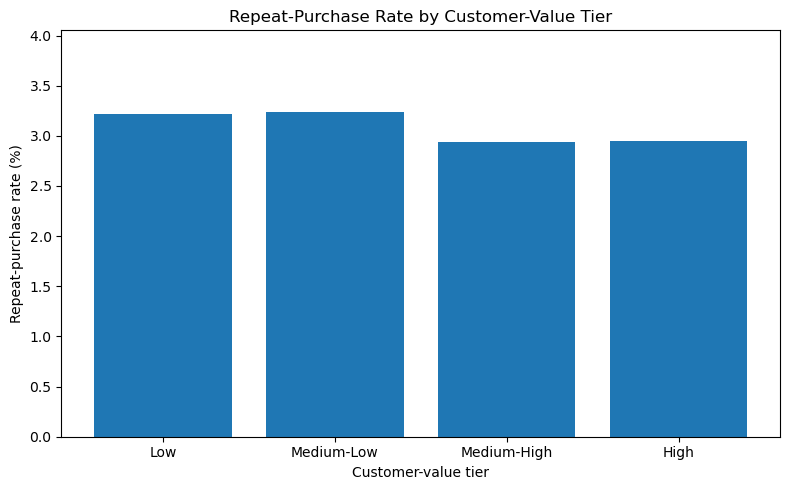

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(
    value_repeat_plot["value_tier"],
    value_repeat_plot["repeat_rate_pct"]
)
plt.ylabel("Repeat-purchase rate (%)")
plt.xlabel("Customer-value tier")
plt.title("Repeat-Purchase Rate by Customer-Value Tier")
plt.ylim(0, max(value_repeat_plot["repeat_rate_pct"]) * 1.25)
plt.tight_layout()
plt.show()

## 12. Delivery vs Value-Tier Analysis

Examine repeat-purchase rates jointly by first-order delivery status and
customer-value tier.

This is a descriptive segmentation view. Formal inference is reserved for
the diagnostic-analysis stage.

In [19]:
delivery_value = con.sql("""
SELECT
    value_tier,
    CASE
        WHEN is_late = 1 THEN 'Late'
        WHEN is_late = 0 THEN 'On-time / early'
        ELSE 'Unclassified'
    END AS delivery_group,
    COUNT(*) AS customers,
    SUM(is_repeat_customer) AS repeat_customers,
    100.0 * AVG(is_repeat_customer) AS repeat_rate_pct
FROM customer_level_featured
GROUP BY value_tier, delivery_group
ORDER BY
    CASE value_tier
        WHEN 'Low' THEN 1
        WHEN 'Medium-Low' THEN 2
        WHEN 'Medium-High' THEN 3
        WHEN 'High' THEN 4
    END,
    CASE delivery_group
        WHEN 'On-time / early' THEN 1
        WHEN 'Late' THEN 2
        ELSE 3
    END
""").df()

display(delivery_value)

,value_tier,delivery_group,customers,repeat_customers,repeat_rate_pct
0,Low,On-time / early,21674,712.0,3.285042
1,Low,Late,1726,41.0,2.375435
2,Medium-Low,On-time / early,21395,694.0,3.243749
3,Medium-Low,Late,1898,61.0,3.213909
4,Medium-High,On-time / early,21499,640.0,2.976883
5,Medium-High,Late,1902,47.0,2.471083
6,High,On-time / early,21094,637.0,3.019816
7,High,Late,2066,45.0,2.178122


### 12.1 Delivery Status × Customer-Value Tier

This chart compares repeat-purchase rates for late and on-time/early first
orders within each customer-value tier.

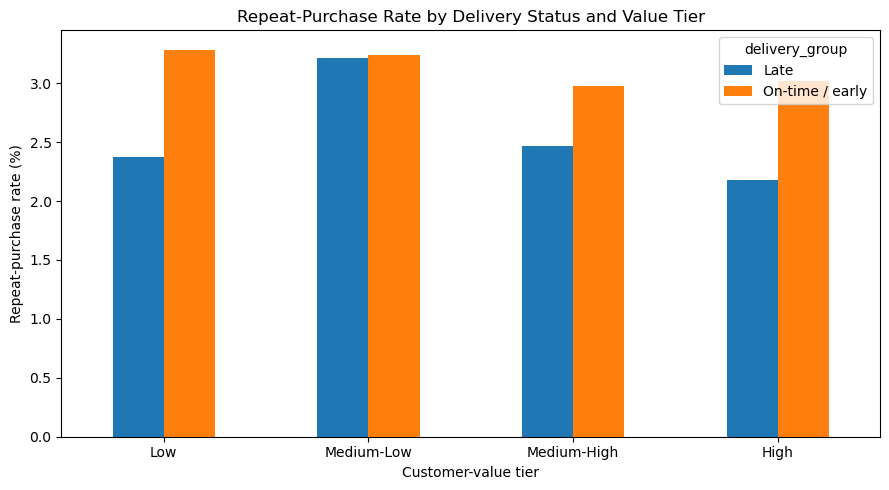

In [20]:
delivery_value_plot = delivery_value.pivot(
    index="value_tier",
    columns="delivery_group",
    values="repeat_rate_pct"
).reindex(["Low", "Medium-Low", "Medium-High", "High"])

ax = delivery_value_plot.plot(
    kind="bar",
    figsize=(9, 5)
)
ax.set_ylabel("Repeat-purchase rate (%)")
ax.set_xlabel("Customer-value tier")
ax.set_title("Repeat-Purchase Rate by Delivery Status and Value Tier")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 13. Feature Quality and Distribution Checks

Check the engineered features for missing values, unusual ranges and
extreme observations.

These checks identify variables that may require robust treatment or careful
interpretation in downstream analysis.

In [21]:
feature_list = [
    "first_order_late_flag",
    "first_order_freight_ratio",
    "first_order_value",
    "first_order_freight",
    "first_order_installments",
    "freight_burden_band",
    "value_tier"
]

con.execute("""
CREATE OR REPLACE TABLE customer_level_featured AS
SELECT
    *,
    is_late AS first_order_late_flag,
    freight_to_price_ratio AS first_order_freight_ratio,
    total_price AS first_order_value,
    total_freight AS first_order_freight,
    max_installments AS first_order_installments
FROM customer_level_featured
""")

feature_quality = con.sql("""
SELECT
    COUNT(*) AS customers,
    SUM(CASE WHEN first_order_late_flag IS NULL THEN 1 ELSE 0 END)
        AS missing_late_flag,
    SUM(CASE WHEN first_order_freight_ratio IS NULL THEN 1 ELSE 0 END)
        AS missing_freight_ratio,
    SUM(CASE WHEN first_order_value IS NULL THEN 1 ELSE 0 END)
        AS missing_order_value,
    SUM(CASE WHEN first_order_freight IS NULL THEN 1 ELSE 0 END)
        AS missing_freight,
    SUM(CASE WHEN first_order_installments IS NULL THEN 1 ELSE 0 END)
        AS missing_installments,
    SUM(CASE WHEN freight_burden_band IS NULL THEN 1 ELSE 0 END)
        AS missing_freight_band,
    SUM(CASE WHEN value_tier IS NULL THEN 1 ELSE 0 END)
        AS missing_value_tier
FROM customer_level_featured
""").df()

display(feature_quality)

display(con.sql("""
SELECT
    MIN(first_order_value) AS min_order_value,
    MAX(first_order_value) AS max_order_value,
    MIN(first_order_freight) AS min_freight,
    MAX(first_order_freight) AS max_freight,
    MIN(first_order_freight_ratio) AS min_freight_ratio,
    MAX(first_order_freight_ratio) AS max_freight_ratio,
    MIN(first_order_installments) AS min_installments,
    MAX(first_order_installments) AS max_installments
FROM customer_level_featured
""").df())

,customers,missing_late_flag,missing_freight_ratio,missing_order_value,missing_freight,missing_installments,missing_freight_band,missing_value_tier
0,93254,0.0,0.0,0.0,0.0,1.0,0.0,0.0


,min_order_value,max_order_value,min_freight,max_freight,min_freight_ratio,max_freight_ratio,min_installments,max_installments
0,0.85,13440.0,0.0,1794.96,0.0,21.447059,0,24


### 13.1 First-Order Order-Value Distribution

The order-value distribution is visualized because the descriptive statistics
show a substantial upper tail.

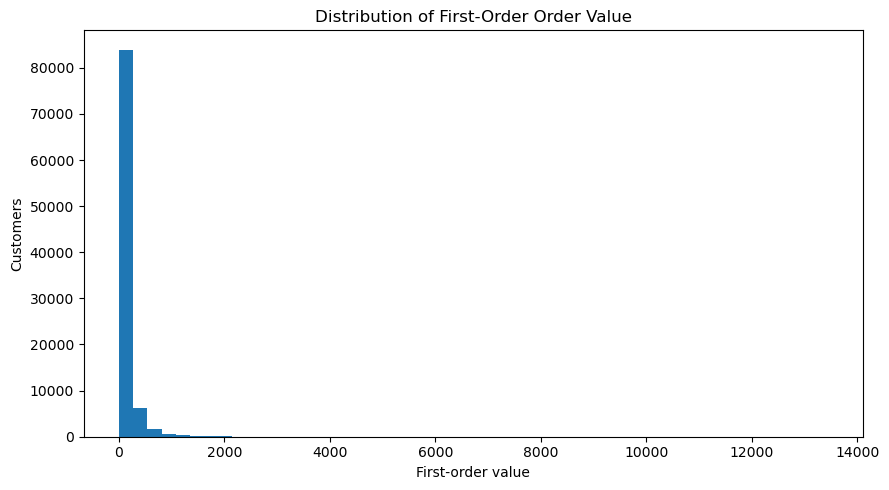

In [22]:
order_value_plot = con.sql("""
SELECT first_order_value
FROM customer_level_featured
WHERE first_order_value IS NOT NULL
""").df()

plt.figure(figsize=(9, 5))
plt.hist(order_value_plot["first_order_value"], bins=50)
plt.xlabel("First-order value")
plt.ylabel("Customers")
plt.title("Distribution of First-Order Order Value")
plt.tight_layout()
plt.show()

### 13.2 Freight-Burden Ratio Distribution

The freight-to-order-value ratio is visualized to show its spread and
upper-tail behaviour.

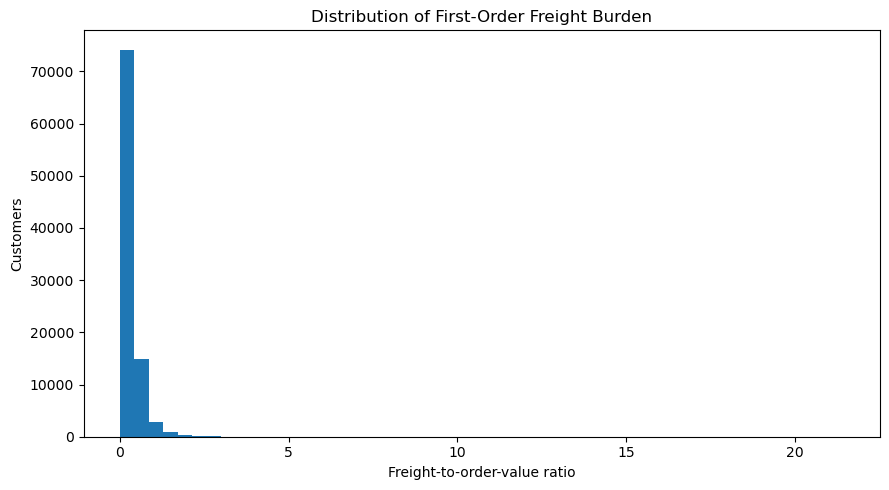

In [23]:
freight_ratio_plot = con.sql("""
SELECT first_order_freight_ratio
FROM customer_level_featured
WHERE first_order_freight_ratio IS NOT NULL
""").df()

plt.figure(figsize=(9, 5))
plt.hist(freight_ratio_plot["first_order_freight_ratio"], bins=50)
plt.xlabel("Freight-to-order-value ratio")
plt.ylabel("Customers")
plt.title("Distribution of First-Order Freight Burden")
plt.tight_layout()
plt.show()

### 13.3 Order Value and Freight Relationship

The scatter plot shows the relationship between first-order value and
first-order freight at customer level.

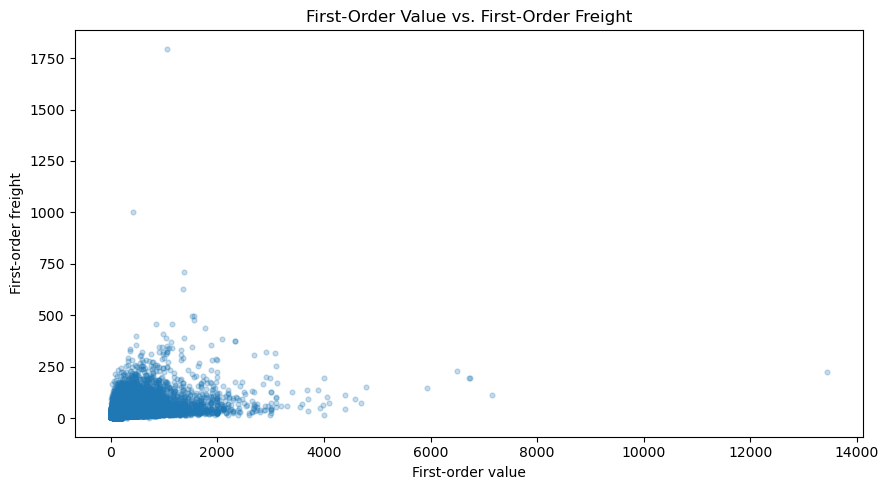

In [24]:
value_freight_plot = con.sql("""
SELECT
    first_order_value,
    first_order_freight
FROM customer_level_featured
WHERE first_order_value IS NOT NULL
  AND first_order_freight IS NOT NULL
""").df()

plt.figure(figsize=(9, 5))
plt.scatter(
    value_freight_plot["first_order_value"],
    value_freight_plot["first_order_freight"],
    alpha=0.25,
    s=12
)
plt.xlabel("First-order value")
plt.ylabel("First-order freight")
plt.title("First-Order Value vs. First-Order Freight")
plt.tight_layout()
plt.show()

### Extreme-Value Review

The following output compares upper-tail values with the median and
interquartile range. It is a descriptive diagnostic, not an outlier-removal
step.

In [25]:
extreme_values = con.sql("""
WITH s AS (
    SELECT
        QUANTILE_CONT(first_order_value, 0.25) AS value_q1,
        QUANTILE_CONT(first_order_value, 0.50) AS value_median,
        QUANTILE_CONT(first_order_value, 0.75) AS value_q3,
        QUANTILE_CONT(first_order_freight, 0.25) AS freight_q1,
        QUANTILE_CONT(first_order_freight, 0.50) AS freight_median,
        QUANTILE_CONT(first_order_freight, 0.75) AS freight_q3,
        QUANTILE_CONT(first_order_freight_ratio, 0.25) AS ratio_q1,
        QUANTILE_CONT(first_order_freight_ratio, 0.50) AS ratio_median,
        QUANTILE_CONT(first_order_freight_ratio, 0.75) AS ratio_q3
    FROM customer_level_featured
)
SELECT
    value_q1, value_median, value_q3,
    value_q3 - value_q1 AS value_iqr,
    value_q3 + 1.5 * (value_q3 - value_q1) AS value_upper_fence,
    freight_q1, freight_median, freight_q3,
    freight_q3 - freight_q1 AS freight_iqr,
    freight_q3 + 1.5 * (freight_q3 - freight_q1) AS freight_upper_fence,
    ratio_q1, ratio_median, ratio_q3,
    ratio_q3 - ratio_q1 AS ratio_iqr,
    ratio_q3 + 1.5 * (ratio_q3 - ratio_q1) AS ratio_upper_fence
FROM s
""").df()

display(extreme_values)

display(con.sql("""
WITH bounds AS (
    SELECT
        QUANTILE_CONT(first_order_value, 0.25) AS v1,
        QUANTILE_CONT(first_order_value, 0.75) AS v3,
        QUANTILE_CONT(first_order_freight, 0.25) AS f1,
        QUANTILE_CONT(first_order_freight, 0.75) AS f3,
        QUANTILE_CONT(first_order_freight_ratio, 0.25) AS r1,
        QUANTILE_CONT(first_order_freight_ratio, 0.75) AS r3
    FROM customer_level_featured
)
SELECT
    SUM(CASE WHEN first_order_value > v3 + 1.5*(v3-v1) THEN 1 ELSE 0 END)
        AS extreme_order_value_rows,
    SUM(CASE WHEN first_order_freight > f3 + 1.5*(f3-f1) THEN 1 ELSE 0 END)
        AS extreme_freight_rows,
    SUM(CASE WHEN first_order_freight_ratio > r3 + 1.5*(r3-r1) THEN 1 ELSE 0 END)
        AS extreme_freight_ratio_rows
FROM customer_level_featured, bounds
""").df())

,value_q1,value_median,value_q3,value_iqr,value_upper_fence,freight_q1,freight_median,freight_q3,freight_iqr,freight_upper_fence,ratio_q1,ratio_median,ratio_q3,ratio_iqr,ratio_upper_fence
0,45.9,86.9,149.9,104.0,305.9,13.85,17.18,24.01,10.16,39.25,0.131864,0.224374,0.380114,0.24825,0.75249


,extreme_order_value_rows,extreme_freight_rows,extreme_freight_ratio_rows
0,7451.0,9349.0,6163.0


### Outlier Treatment — Winsorized Columns for Sensitivity Checking

The extreme-value review above was descriptive only; no values were
removed or adjusted. Because several downstream business metrics
(Segment Expected Repeat Revenue, delivery-opportunity estimates) are
built on the **mean** of `first_order_value` and `first_order_freight`,
extreme upper-tail orders could disproportionately influence those
dollar-denominated figures, particularly within the highest value tier.

Rather than remove or silently cap the original values (which would
change the population used in the formal H1/H2 tests), two **winsorized
copies** are added at the 1st/99th percentile. These are used only for a
side-by-side sensitivity comparison later during analysis — the original,
uncapped columns remain the columns of record for all statistical testing.


In [26]:
con.execute("""
CREATE OR REPLACE TABLE customer_level_featured AS
WITH bounds AS (
    SELECT
        QUANTILE_CONT(first_order_value, 0.01) AS value_p1,
        QUANTILE_CONT(first_order_value, 0.99) AS value_p99,
        QUANTILE_CONT(first_order_freight, 0.01) AS freight_p1,
        QUANTILE_CONT(first_order_freight, 0.99) AS freight_p99
    FROM customer_level_featured
)
SELECT
    c.*,
    LEAST(GREATEST(c.first_order_value, b.value_p1), b.value_p99)
        AS first_order_value_winsorized,
    LEAST(GREATEST(c.first_order_freight, b.freight_p1), b.freight_p99)
        AS first_order_freight_winsorized
FROM customer_level_featured c, bounds b
""")

print("Added: first_order_value_winsorized, first_order_freight_winsorized "
      "(1st/99th percentile caps).")


Added: first_order_value_winsorized, first_order_freight_winsorized (1st/99th percentile caps).


In [27]:
sensitivity = con.sql("""
SELECT
    value_tier,
    COUNT(*) AS customers,
    AVG(first_order_value) AS mean_order_value,
    MEDIAN(first_order_value) AS median_order_value,
    AVG(first_order_value_winsorized) AS winsorized_mean_order_value,
    AVG(first_order_freight) AS mean_freight,
    AVG(first_order_freight_winsorized) AS winsorized_mean_freight,
    100.0 * (AVG(first_order_value) - AVG(first_order_value_winsorized))
        / NULLIF(AVG(first_order_value_winsorized), 0)
        AS pct_shift_from_winsorizing
FROM customer_level_featured
WHERE value_tier IS NOT NULL
GROUP BY value_tier
ORDER BY
    CASE value_tier
        WHEN 'Low' THEN 1
        WHEN 'Medium-Low' THEN 2
        WHEN 'Medium-High' THEN 3
        WHEN 'High' THEN 4
    END
""").df()

display(sensitivity)

max_shift = sensitivity["pct_shift_from_winsorizing"].abs().max()
print(f"\nLargest mean shift from winsorizing: {max_shift:.2f}%")
if max_shift > 5:
    print(
        "CAUTION: the raw mean differs from the winsorized mean by more "
        "than 5% in at least one tier. Dollar-denominated business metrics "
        "in Notebook 05 built on the raw mean should be reported alongside "
        "the winsorized version for that tier as a robustness check."
    )
else:
    print(
        "Winsorizing shifts the mean by less than 5% in every tier. Extreme "
        "values are not materially distorting the mean-based business "
        "metrics, so the raw (uncapped) mean can be used with a documented "
        "note rather than requiring a full re-run on winsorized values."
    )


,value_tier,customers,mean_order_value,median_order_value,winsorized_mean_order_value,mean_freight,winsorized_mean_freight,pct_shift_from_winsorizing
0,Low,23400,28.613741,29.00,28.718382,15.217392,15.213537,-0.36437
1,Medium-Low,23293,63.944420,60.00,63.944420,18.111460,18.119539,0.00000
2,Medium-High,23401,115.103533,113.45,115.103533,22.813492,22.808795,0.00000
3,High,23160,344.036777,230.00,320.063865,35.066088,32.920515,7.49004



Largest mean shift from winsorizing: 7.49%
CAUTION: the raw mean differs from the winsorized mean by more than 5% in at least one tier. Dollar-denominated business metrics in Notebook 05 built on the raw mean should be reported alongside the winsorized version for that tier as a robustness check.


### Outlier Sensitivity — Result

The largest mean shift from winsorizing occurs in the High value tier: the raw mean order value is R$344.04, versus R$320.06 winsorized (1st/99th percentile capped) — a 7.49% shift, exceeding the 5% caution threshold. All other tiers shift by less than 0.4%. Freight shows a similar pattern in the High tier (R$35.07 raw vs. R$32.92 winsorized).


## 14. EDA Summary

Record the principal descriptive patterns observed in the notebook.

Do not state statistical significance or causality here. Formal inference is
performed in the next diagnostic-analysis notebook.

The summary below is generated from the descriptive tables above so that the
reported values remain consistent with the analysis population.

In [28]:
summary_stats = con.sql("""
WITH overall AS (
    SELECT
        COUNT(*) AS customers,
        SUM(is_repeat_customer) AS repeat_customers,
        100.0 * AVG(is_repeat_customer) AS repeat_rate_pct,
        100.0 * AVG(CASE WHEN is_late IS NOT NULL THEN is_late END)
            AS late_rate_pct
    FROM customer_level_featured
),
delivery AS (
    SELECT
        100.0 * AVG(CASE WHEN is_late = 0 THEN is_repeat_customer END)
            AS on_time_repeat_rate_pct,
        100.0 * AVG(CASE WHEN is_late = 1 THEN is_repeat_customer END)
            AS late_repeat_rate_pct
    FROM customer_level_featured
)
SELECT * FROM overall CROSS JOIN delivery
""").df()

display(summary_stats)

print("Descriptive observations:")
row = summary_stats.iloc[0]

print(
    f"1. The analytical population contains {int(row['customers']):,} customers, "
    f"of whom {int(row['repeat_customers']):,} are repeat customers "
    f"({row['repeat_rate_pct']:.2f}%)."
)
print(
    f"2. The first-order late-delivery rate is {row['late_rate_pct']:.2f}%."
)
print(
    f"3. Repeat-purchase rate is {row['on_time_repeat_rate_pct']:.2f}% "
    f"for on-time/early first orders and {row['late_repeat_rate_pct']:.2f}% "
    f"for late first orders."
)

high_low_freight = freight_repeat.iloc[[0, -1]]
print(
    f"4. Repeat rate ranges from {high_low_freight.iloc[0]['repeat_rate_pct']:.2f}% "
    f"in the lowest freight-burden band to "
    f"{high_low_freight.iloc[1]['repeat_rate_pct']:.2f}% in the highest band."
)

high_low_value = value_repeat.iloc[[0, -1]]
print(
    f"5. Repeat rate ranges from {high_low_value.iloc[0]['repeat_rate_pct']:.2f}% "
    f"in the Low value tier to "
    f"{high_low_value.iloc[1]['repeat_rate_pct']:.2f}% in the High value tier."
)

print(
    "6. The Delivery × Value-Tier table above shows how the descriptive "
    "delivery pattern varies across customer-value segments."
)

print(
    "7. Order value, freight and freight-burden ratio show upper-tail "
    "observations that should be considered in downstream analysis."
)

,customers,repeat_customers,repeat_rate_pct,late_rate_pct,on_time_repeat_rate_pct,late_repeat_rate_pct
0,93254,2877.0,3.085122,8.141206,3.132077,2.555321


Descriptive observations:
1. The analytical population contains 93,254 customers, of whom 2,877 are repeat customers (3.09%).
2. The first-order late-delivery rate is 8.14%.
3. Repeat-purchase rate is 3.13% for on-time/early first orders and 2.56% for late first orders.
4. Repeat rate ranges from 3.16% in the lowest freight-burden band to 3.17% in the highest band.
5. Repeat rate ranges from 3.22% in the Low value tier to 2.94% in the High value tier.
6. The Delivery × Value-Tier table above shows how the descriptive delivery pattern varies across customer-value segments.
7. Order value, freight and freight-burden ratio show upper-tail observations that should be considered in downstream analysis.


## 15. Feature Dictionary

The engineered variables are retained with clear analytical meanings.

In [29]:
feature_dictionary = pd.DataFrame({
    "feature": [
        "first_order_late_flag",
        "first_order_freight_ratio",
        "first_order_value",
        "first_order_freight",
        "first_order_installments",
        "freight_burden_band",
        "value_tier",
        "is_repeat_customer"
    ],
    "meaning": [
        "Whether the customer's first order was delivered after the estimated date",
        "First-order freight divided by first-order order value",
        "First-order total order value",
        "First-order total freight value",
        "Maximum payment installment count on the first order",
        "Quartile-based first-order freight burden segment",
        "Quartile-based first-order customer value segment",
        "Whether the customer placed more than one order"
    ]
})

display(feature_dictionary)

display(con.sql("""
SELECT
    COUNT(*) AS customers,
    COUNT(DISTINCT customer_unique_id) AS unique_customers,
    COUNT(*) - COUNT(DISTINCT customer_unique_id) AS duplicate_customers
FROM customer_level_featured
""").df())

,feature,meaning
0,first_order_late_flag,Whether the customer's first order was deliver...
1,first_order_freight_ratio,First-order freight divided by first-order ord...
2,first_order_value,First-order total order value
3,first_order_freight,First-order total freight value
4,first_order_installments,Maximum payment installment count on the first...
5,freight_burden_band,Quartile-based first-order freight burden segment
6,value_tier,Quartile-based first-order customer value segment
7,is_repeat_customer,Whether the customer placed more than one order


,customers,unique_customers,duplicate_customers
0,93254,93254,0


## 16. Feature-Engineered Dataset

The feature-engineered customer-level table is retained in the analytical
data layer and exported as a CSV convenience copy.

The original customer-level analytical table is not overwritten.

In [30]:
FEATURED_CSV = ANALYTICAL_DIR / "customer_level_featured.csv"

customer_featured = con.sql("""
SELECT *
FROM customer_level_featured
""").df()

customer_featured.to_csv(FEATURED_CSV, index=False)

print("Feature engineering completed.")
print(f"DuckDB table: customer_level_featured")
print(f"CSV copy: {FEATURED_CSV}")
print(
    f"Dimensions: {customer_featured.shape[0]:,} rows × "
    f"{customer_featured.shape[1]:,} columns"
)

Feature engineering completed.
DuckDB table: customer_level_featured
CSV copy: d:\Learning\Data Science\Capstone Project\Final_Project_Olist_BYOC_Capstone\02_Data\03_Analytical\customer_level_featured.csv
Dimensions: 93,254 rows × 53 columns


## 17. Validation

The final dataset must remain at one row per customer and retain the target
variable required by the diagnostic analysis.

In [31]:
final_check = con.sql("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT customer_unique_id) AS unique_customers,
    COUNT(*) - COUNT(DISTINCT customer_unique_id) AS duplicate_customer_rows,
    SUM(is_repeat_customer) AS repeat_customers,
    SUM(CASE WHEN first_order_late_flag IS NULL THEN 1 ELSE 0 END)
        AS missing_late_flag,
    SUM(CASE WHEN first_order_freight_ratio IS NULL THEN 1 ELSE 0 END)
        AS missing_freight_ratio,
    SUM(CASE WHEN first_order_value IS NULL THEN 1 ELSE 0 END)
        AS missing_order_value,
    SUM(CASE WHEN freight_burden_band IS NULL THEN 1 ELSE 0 END)
        AS missing_freight_band,
    SUM(CASE WHEN value_tier IS NULL THEN 1 ELSE 0 END)
        AS missing_value_tier
FROM customer_level_featured
""").df()

display(final_check)

con.close()
print("DuckDB connection closed.")

,rows,unique_customers,duplicate_customer_rows,repeat_customers,missing_late_flag,missing_freight_ratio,missing_order_value,missing_freight_band,missing_value_tier
0,93254,93254,0,2877.0,0.0,0.0,0.0,0.0,0.0


DuckDB connection closed.


## Summary

The customer-level analytical population has been explored and enriched with
first-order delivery, freight, order-value and payment features.

Quartile-based freight-burden bands and customer-value tiers have been created,
and descriptive repeat-purchase comparisons have been produced.

No formal hypothesis test or predictive model is performed in this notebook.
The resulting `customer_level_featured` table is ready for diagnostic analysis.